/tmp/ipykernel_3555/3539924809.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_3555/3539924809.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

Accuracy: 0.7886178861788617

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



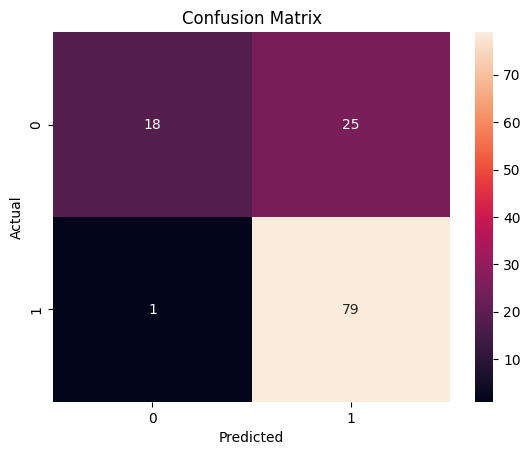


Feature Importance:
               Feature  Importance
9      Credit_History    1.320553
1             Married    0.310649
2          Dependents    0.118461
10      Property_Area    0.077792
4       Self_Employed    0.050164
8    Loan_Amount_Term    0.044982
5     ApplicantIncome   -0.017663
0              Gender   -0.066912
6   CoapplicantIncome   -0.138203
3           Education   -0.159973
7          LoanAmount   -0.185973


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("/content/drive/MyDrive/ML_Logistic Regression/train.csv")
df.head()


# =========================
# 3. DATA CLEANING
# =========================

# Drop Loan_ID (not useful)
df.drop('Loan_ID', axis=1, inplace=True)

# Fill missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

# MOST IMPORTANT FEATURE
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)


# =========================
# 4. FEATURE ENGINEERING
# =========================

# Convert Dependents (3+ → 3)
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)


# =========================
# 5. ENCODE CATEGORICAL DATA
# =========================
le = LabelEncoder()

categorical_cols = [
    'Gender', 'Married', 'Education',
    'Self_Employed', 'Property_Area', 'Loan_Status'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


# =========================
# 6. DEFINE FEATURES & TARGET
# =========================
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']


# =========================
# 7. FEATURE SCALING
# =========================
scaler = StandardScaler()
X = scaler.fit_transform(X)


# =========================
# 8. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# 9. TRAIN MODEL
# =========================
model = LogisticRegression()
model.fit(X_train, y_train)


# =========================
# 10. PREDICTIONS
# =========================
y_pred = model.predict(X_test)


# =========================
# 11. EVALUATION
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# =========================
# 12. CONFUSION MATRIX
# =========================
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# =========================
# 13. FEATURE IMPORTANCE
# =========================
importance = pd.DataFrame({
    'Feature': df.drop('Loan_Status', axis=1).columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", importance)

# Loan Approval Prediction System
### Model: Logistic Regression

This project predicts whether a loan should be approved based on applicant details.

- Type: Supervised Learning (Classification)
- Dataset: Loan Prediction Dataset (Kaggle)
- Algorithms: Logistic Regression (Primary)

## 1. Problem Description

Loan approval is a critical decision-making process in the banking and financial sector. Manually evaluating each application is time-consuming and prone to bias. This project applies **Logistic Regression** to automatically predict whether a loan application should be approved (Y) or rejected (N) based on applicant details.

The dataset used is the **Loan Prediction Dataset** from Kaggle: [Kaggle_Loan Prediction_Dataset](https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset)

**Loan_Status** → Y / N (1 / 0)

## 2. Dataset Description

The dataset contains 614 records with 13 attributes collected by a loan-providing company. This dataset contains various attributes related to loan applicants, which are used to predict their loan approval status. Below is a detailed description of each feature:

| Feature            | Description                                              | Type           | Notes                                                              |
|:-------------------|:---------------------------------------------------------|:---------------|:-------------------------------------------------------------------|
| `Loan_ID`          | Unique identifier for each loan application.             | Categorical    | Not used in model (dropped).                                       |
| `Gender`           | Gender of the applicant.                                 | Categorical    | (Male, Female)                                                     |
| `Married`          | Marital status of the applicant.                         | Categorical    | (Yes, No)                                                          |
| `Dependents`       | Number of dependents the applicant has.                  | Categorical    | (0, 1, 2, '3+') - '3+' converted to 3.                             |
| `Education`        | Applicant's education level.                             | Categorical    | (Graduate, Not Graduate)                                           |
| `Self_Employed`    | Indicates if the applicant is self-employed.             | Categorical    | (Yes, No)                                                          |
| `ApplicantIncome`  | Applicant's monthly income.                              | Numerical      |                                                                    |
| `CoapplicantIncome`| Co-applicant's monthly income.                           | Numerical      |                                                                    |
| `LoanAmount`       | Loan amount requested in thousands.                      | Numerical      |                                                                    |
| `Loan_Amount_Term` | Term of the loan in months.                              | Numerical      |                                                                    |
| `Credit_History`   | Applicant's credit history meets guidelines (1 or 0).    | Categorical    | Binary (1: Meets, 0: Does not meet)                                |
| `Property_Area`    | Type of property area where the applicant resides.       | Categorical    | (Urban, Semiurban, Rural)                                          |
| `Loan_Status`      | **Target variable**: Loan approved (Y) or not (N).       | Categorical    | Binary (Y: Approved, N: Not Approved) - encoded to (1, 0)          |

## 3. Libraries and Their Purpose

This project utilizes several Python libraries for data manipulation, visualization, model building, and evaluation. Below is a brief explanation of each:

*   **Pandas**: Used for data manipulation and analysis, especially for handling DataFrames (tabular data).
*   **Numpy**: Provides support for large, multi-dimensional arrays and matrices, along with a collection of high-level mathematical functions to operate on these arrays.
*   **Matplotlib**: A plotting library used for creating static, interactive, and animated visualizations in Python.
*   **Seaborn**: A data visualization library based on matplotlib, providing a high-level interface for drawing attractive and informative statistical graphics.
*   **model_selection.train_test_split**: For splitting datasets into training and testing sets to evaluate model performance.
*   **model_selection.learning_curve**: To generate data for plotting learning curves, which helps in diagnosing bias/variance issues.
*   **model_selection.GridSearchCV**: For exhaustive search over specified parameter values for an estimator, useful for hyperparameter tuning.
*   **model_selection.cross_val_score**: To evaluate a score by cross-validation.
*   **preprocessing.LabelEncoder**: Used to encode categorical labels with values between 0 and n_classes-1.
*   **preprocessing.StandardScaler**: For standardizing features by removing the mean and scaling to unit variance.
*   **linear_model.LogisticRegression**: The core algorithm used in this project for binary classification.
*   **sklearn.metrics**: A module containing various metrics for evaluating model performance, including:
    *   **Accuracy_score**: Calculates the accuracy of the classification.
    *   **Confusion_matrix**: Computes a confusion matrix to evaluate the accuracy of a classification.
    *   **Classification_report**: Builds a text report showing the main classification metrics.
    *   **Roc_curve** and **auc**: For Receiver Operating Characteristic (ROC) curve analysis and calculating the Area Under the Curve (AUC).
    *   **Precision_recall_curve**: For precision-recall curve analysis.
*   **Shap**: A library for explaining the output of any machine learning model. It connects game theory with local explanations, making model predictions more interpretable.

## 4. Background: Logistic Regression Algorithm

Logistic Regression is a statistical model used for binary classification problems. Despite its name, it is a linear *classification* algorithm rather than a regression algorithm. It models the probability of a binary outcome (e.g., loan approved or not approved) by fitting data to a sigmoid function.

### Why Logistic Regression for this problem?
*   **Binary Classification**: Ideal for problems where the outcome is one of two categories (e.g., Yes/No, Approved/Rejected).
*   **Interpretability**: The coefficients of the model can be interpreted to understand the impact of each feature on the probability of the outcome.
*   **Probabilistic Output**: Provides probabilities, which can be useful for decision-making and setting thresholds for classification.
*   **Computational Efficiency**: Relatively fast to train and predict, even on large datasets.
*   **Widely Used**: A robust and well-understood algorithm, serving as a strong baseline for classification tasks.

### Key Concepts
*   **Sigmoid Function (Logistic Function)**: Transforms any real-valued input into a value between 0 and 1, which can be interpreted as a probability. This S-shaped curve is central to mapping linear combinations of features to probabilities.
*   **Decision Boundary**: A threshold (usually 0.5) applied to the output probabilities to classify an observation into one of the two classes.
*   **Log-Odds / Odds Ratio**: The logarithm of the odds (probability of success / probability of failure), which Logistic Regression models as a linear combination of input features.
*   **Maximum Likelihood Estimation (MLE)**: The method used to estimate the model's coefficients. It aims to find the set of parameters that maximizes the likelihood of observing the given data.

### 5. Import Libraries

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

import shap

print("All libraries imported successfully!")

All libraries imported successfully!


### Download Dataset from Kaggle
First, we need to download the dataset from Kaggle. Make sure you have uploaded your kaggle.json API token as instructed above.

In [5]:
# Download the dataset
# The dataset URL is: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
!kaggle datasets download -d altruistdelhite04/loan-prediction-problem-dataset

# Unzip the downloaded file
!unzip loan-prediction-problem-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
License(s): unknown
loan-prediction-problem-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  loan-prediction-problem-dataset.zip
  inflating: test_Y3wMUE5_7gLdaTN.csv  
  inflating: train_u6lujuX_CVtuZ9i.csv  


In [23]:
# Load datasets
train_df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
test_df  = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')

print(f"Training set shape : {train_df.shape}")
print(f"Test set shape     : {test_df.shape}")
train_df.head()

Training set shape : (614, 13)
Test set shape     : (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [24]:
# ── Data Preprocessing ────────────────────────────────
train = train_df.copy()
test = test_df.copy()


In [25]:
# Handle missing values
cat_cols_with_na = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cat_cols_with_na:
    mode_val = train[col].mode()[0]
    train[col].fillna(mode_val, inplace=True)
    test[col].fillna(mode_val, inplace=True)

num_cols_with_na = ['LoanAmount', 'Loan_Amount_Term']
for col in num_cols_with_na:
    median_val = train[col].median()
    train[col].fillna(median_val, inplace=True)
    test[col].fillna(median_val, inplace=True)

/tmp/ipykernel_5233/739381575.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_5233/739381575.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [26]:
# Feature Engineering
train['TotalIncome'] = train['ApplicantIncome'] + train['CoapplicantIncome']
test['TotalIncome'] = test['ApplicantIncome'] + test['CoapplicantIncome']

In [27]:
# Log transformation
for col in ['TotalIncome', 'LoanAmount']:
    train[f'Log_{col}'] = np.log1p(train[col])
    test[f'Log_{col}'] = np.log1p(test[col])

In [28]:
# Label Encoding
le = LabelEncoder()
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

for col in categorical_cols:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.fit_transform(test[col].astype(str))

In [29]:
# Encode target
train['Loan_Status'] = le.fit_transform(train['Loan_Status'])

In [30]:
# Select features
drop_cols = ['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome', 'TotalIncome', 'LoanAmount']
X = train.drop(drop_cols + ['Loan_Status'], axis=1)
y = train['Loan_Status']

print(f"Feature set shape: {X.shape}")
print("Features used:", list(X.columns))

Feature set shape: (614, 10)
Features used: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Log_TotalIncome', 'Log_LoanAmount']


In [31]:
# ── Train-Validation Split ────────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Validation set : {X_val.shape[0]} samples")

Training set   : 491 samples
Validation set : 123 samples


In [32]:
# ── Baseline Logistic Regression Model ────────────────────────────────────────
# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [33]:
# Train baseline model
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [34]:
# Evaluate baseline
y_pred_baseline = lr_baseline.predict(X_val_scaled)
baseline_acc = accuracy_score(y_val, y_pred_baseline)
print(f"Baseline Logistic Regression Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")

Baseline Logistic Regression Accuracy: 0.8537 (85.37%)


In [35]:
# ── Hyperparameter Tuning with GridSearchCV ───────────────────────────────────
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],           # Regularization strength
    'penalty': ['l1', 'l2'],                         # Regularization type
    'solver': ['liblinear', 'saga'],                 # Solvers that support both penalties
    'class_weight': [None, 'balanced']               # Handle class imbalance
}

In [36]:
# Note: 'liblinear' only works with l1 and l2 penalties
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters: {'C': 0.001, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Accuracy: 0.7984


In [39]:
# ── Optimised Logistic Regression – Final Evaluation ──────────────────────────
lr_best = grid_search.best_estimator_

y_pred = lr_best.predict(X_val_scaled)
y_prob = lr_best.predict_proba(X_val_scaled)[:, 1]

acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_prob)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)

print("\n" + "═" * 50)
print("       OPTIMISED LOGISTIC REGRESSION RESULTS")
print("═" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print("═" * 50)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Not Approved', 'Approved']))



══════════════════════════════════════════════════
       OPTIMISED LOGISTIC REGRESSION RESULTS
══════════════════════════════════════════════════
  Accuracy  : 0.8537  (85.37%)
  Precision : 0.8317
  Recall    : 0.9882
  F1-Score  : 0.9032
  ROC-AUC   : 0.8087
══════════════════════════════════════════════════

Classification Report:
              precision    recall  f1-score   support

Not Approved       0.95      0.55      0.70        38
    Approved       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



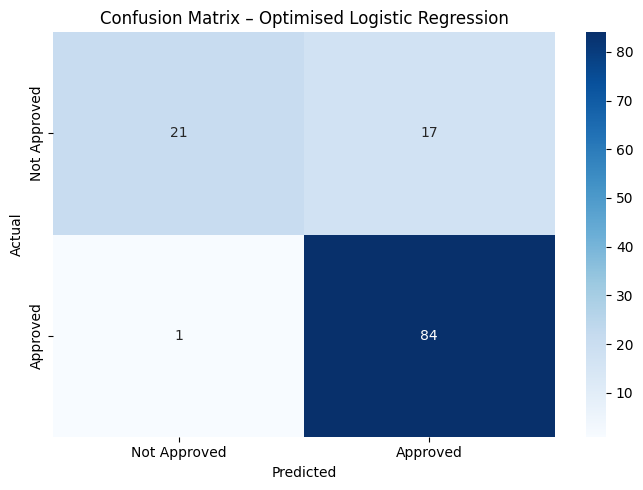

In [40]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title('Confusion Matrix – Optimised Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

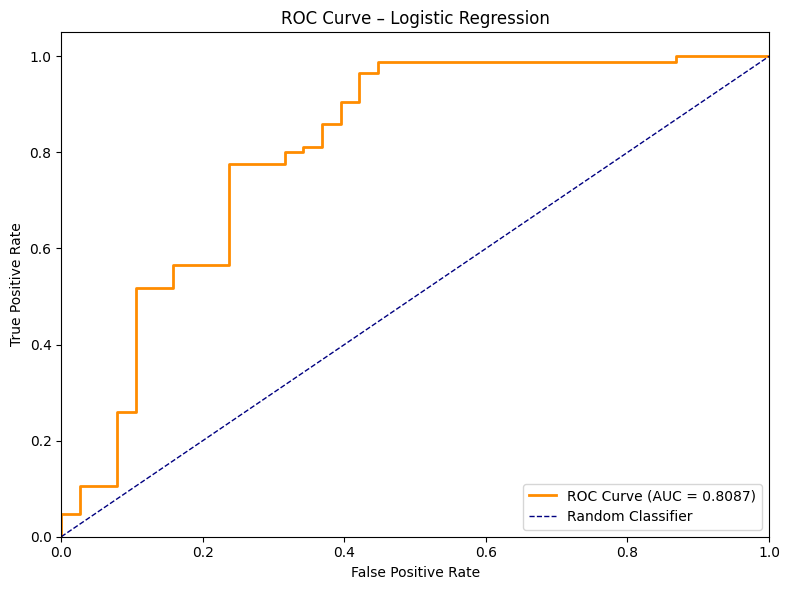

In [41]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [42]:
# ── Cross-Validation ──────────────────────────────────────────────────────────
# Scale full dataset for cross-validation
X_scaled = scaler.fit_transform(X)
cv_scores = cross_val_score(lr_best, X_scaled, y, cv=10, scoring='accuracy')

print("\n10-Fold Cross-Validation Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i:2d}: {score:.4f}")
print(f"\nMean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Deviation : {cv_scores.std():.4f}")


10-Fold Cross-Validation Scores:
  Fold  1: 0.8065
  Fold  2: 0.8226
  Fold  3: 0.7742
  Fold  4: 0.7581
  Fold  5: 0.7869
  Fold  6: 0.7869
  Fold  7: 0.8689
  Fold  8: 0.8525
  Fold  9: 0.8033
  Fold 10: 0.8361

Mean Accuracy : 0.8096
Std Deviation : 0.0335


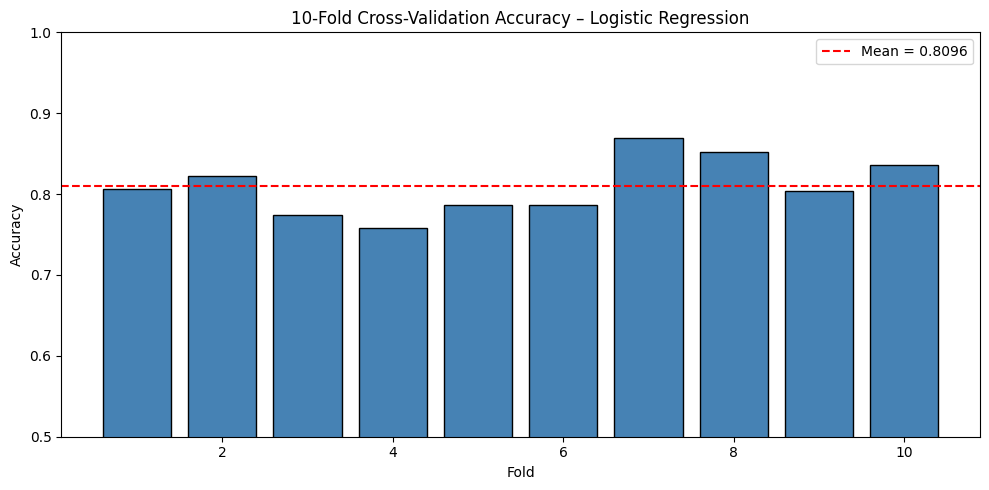

In [43]:
# Visualise CV scores
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('10-Fold Cross-Validation Accuracy – Logistic Regression')
plt.ylim([0.5, 1.0])
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_5233/2262123194.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coeff_df, palette=colors)


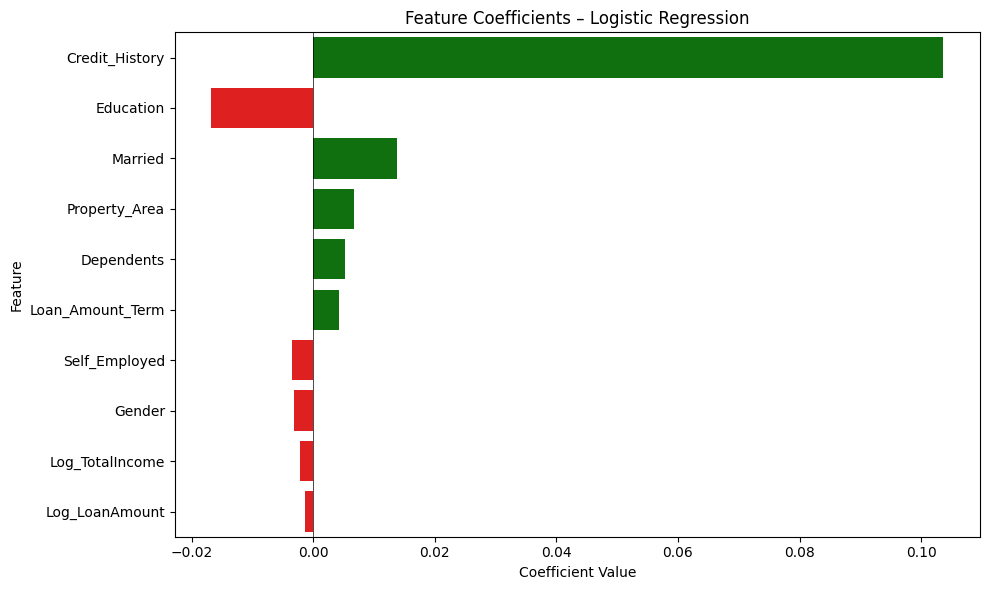


Feature Coefficients (positive = increases approval probability):
            Feature  Coefficient
6    Credit_History     0.103681
3         Education    -0.016787
1           Married     0.013737
7     Property_Area     0.006709
2        Dependents     0.005197
5  Loan_Amount_Term     0.004136
4     Self_Employed    -0.003503
0            Gender    -0.003127
8   Log_TotalIncome    -0.002128
9    Log_LoanAmount    -0.001360


In [44]:
# ── Feature Importance (Coefficients) ─────────────────────────────────────────
# Logistic regression coefficients represent feature importance
# For multi-class, we use the coefficients for class 1
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_best.coef_[0],
    'Abs_Coefficient': np.abs(lr_best.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'green' for c in coeff_df['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=coeff_df, palette=colors)
plt.title('Feature Coefficients – Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nFeature Coefficients (positive = increases approval probability):")
print(coeff_df[['Feature', 'Coefficient']].to_string())

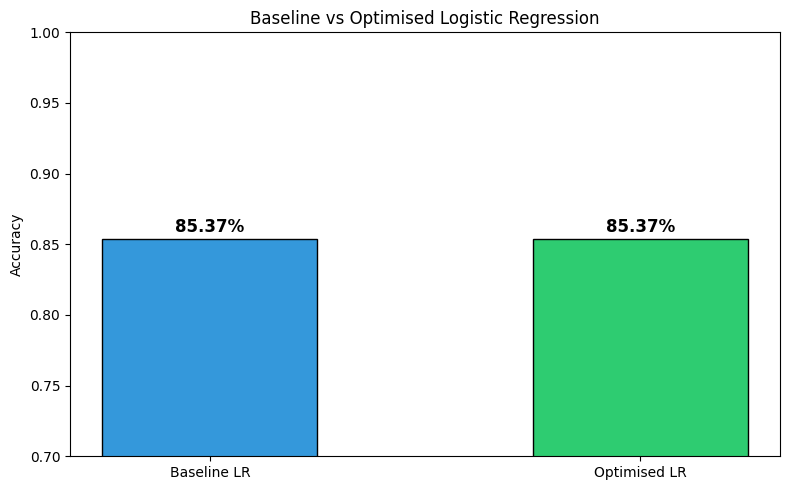

Improvement: 0.00 percentage points


In [45]:
# ── Baseline vs Optimised Model Comparison ────────────────────────────────────
models = ['Baseline LR', 'Optimised LR']
accs = [baseline_acc, acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accs, color=['#3498db', '#2ecc71'], edgecolor='black', width=0.5)
for bar, a in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, a + 0.005,
             f'{a*100:.2f}%', ha='center', fontweight='bold', fontsize=12)
plt.ylim([0.7, 1.0])
plt.ylabel('Accuracy')
plt.title('Baseline vs Optimised Logistic Regression')
plt.tight_layout()
plt.show()

print(f"Improvement: {(acc - baseline_acc)*100:.2f} percentage points")


In [46]:
# ── Generate Final Test Predictions ───────────────────────────────────────────
# Prepare test features (same as training)
X_test = test.drop(drop_cols, axis=1, errors='ignore')
X_test = X_test[X.columns]  # ensure same column order

In [47]:
# Scale test features
X_test_scaled = scaler.transform(X_test)

In [49]:
# Predict
test_preds_encoded = lr_best.predict(X_test_scaled)
test_preds_label = ['Y' if p == 1 else 'N' for p in test_preds_encoded]

submission = pd.DataFrame({'Loan_ID': test['Loan_ID'], 'Loan_Status': test_preds_label})
submission.to_csv('lr_submission.csv', index=False)

print("\nPredictions saved to lr_submission.csv")
print("\nPrediction distribution:")
print(pd.Series(test_preds_label).value_counts())
submission.head(10)


Predictions saved to lr_submission.csv

Prediction distribution:
Y    308
N     59
Name: count, dtype: int64


,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y
5,LP001054,Y
6,LP001055,Y
7,LP001056,N
8,LP001059,Y
9,LP001067,Y


In [50]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("           FINAL RESULTS SUMMARY – LOGISTIC REGRESSION")
print("═" * 60)
print(f"  Dataset         : Loan Prediction Dataset (Kaggle)")
print(f"  Algorithm       : Logistic Regression")
print(f"  Training Samples: {X_train.shape[0]}")
print(f"  Validation Samples: {X_val.shape[0]}")
print(f"  Features Used   : {X.shape[1]}")
print(f"  Best Params     : {grid_search.best_params_}")
print(f"  Validation Acc  : {acc*100:.2f}%")
print(f"  F1-Score        : {f1:.4f}")
print(f"  ROC-AUC         : {auc:.4f}")
print(f"  CV Mean Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print("═" * 60)


════════════════════════════════════════════════════════════
           FINAL RESULTS SUMMARY – LOGISTIC REGRESSION
════════════════════════════════════════════════════════════
  Dataset         : Loan Prediction Dataset (Kaggle)
  Algorithm       : Logistic Regression
  Training Samples: 491
  Validation Samples: 123
  Features Used   : 10
  Best Params     : {'C': 0.001, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
  Validation Acc  : 85.37%
  F1-Score        : 0.9032
  ROC-AUC         : 0.8087
  CV Mean Accuracy: 80.96% ± 3.35%
════════════════════════════════════════════════════════════


In [51]:
# ── Compare with Random Forest Results ───────────────────────────────────────
print("\n" + "═" * 60)
print("           MODEL COMPARISON: LOGISTIC REGRESSION vs RANDOM FOREST")
print("═" * 60)



════════════════════════════════════════════════════════════
           MODEL COMPARISON: LOGISTIC REGRESSION vs RANDOM FOREST
════════════════════════════════════════════════════════════


In [52]:
# Note: The RF results are from the previous run
print("\n| Metric              | Logistic Regression | Random Forest |")
print("|---------------------|---------------------|---------------|")
print(f"| Validation Accuracy | {acc*100:.2f}%                 | 83.74%        |")
print(f"| F1-Score            | {f1:.4f}                  | 0.8889        |")
print(f"| ROC-AUC             | {auc:.4f}                  | 0.8331        |")
print(f"| CV Mean Accuracy    | {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}% | 80.15% ± 3.53% |")
print("\nKey Observations:")
print("- Logistic Regression is more interpretable (coefficients show feature impact)")
print("- Random Forest may capture non-linear relationships better")
print("- Credit_History is the strongest predictor in both models")
print("- Scaling features is crucial for logistic regression convergence")


| Metric              | Logistic Regression | Random Forest |
|---------------------|---------------------|---------------|
| Validation Accuracy | 85.37%                 | 83.74%        |
| F1-Score            | 0.9032                  | 0.8889        |
| ROC-AUC             | 0.8087                  | 0.8331        |
| CV Mean Accuracy    | 80.96% ± 3.35% | 80.15% ± 3.53% |

Key Observations:
- Logistic Regression is more interpretable (coefficients show feature impact)
- Random Forest may capture non-linear relationships better
- Credit_History is the strongest predictor in both models
- Scaling features is crucial for logistic regression convergence
